# Instructor Effectiveness Modeling

This notebook analyzes instructor effectiveness for an EdTech platform.

Each row in the dataset represents a course batch taught by an instructor. Since instructors may teach multiple batches, the goal is to:

1. Explore the dataset and understand patterns in learner outcomes, engagement, and feedback.
2. Define an Instructor Effectiveness Score based on available metrics.
3. Aggregate batch-level data to instructor-level features.
4. Train a machine learning model to predict instructor effectiveness tiers.
5. Interpret model results and discuss limitations.

The goal is not only to build a predictive model but also to understand which factors influence instructor effectiveness.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


The dataset contains batch-level records where each row corresponds to a course batch.
Multiple batches may belong to the same instructor.

Key categories of features include:

• Learner Outcomes (completion_rate, dropout_rate, quiz scores)
• Engagement Metrics (watch time, assignments, forum activity)
• Feedback Metrics (ratings and response rates)

In [4]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


Exploratory Data Analysis

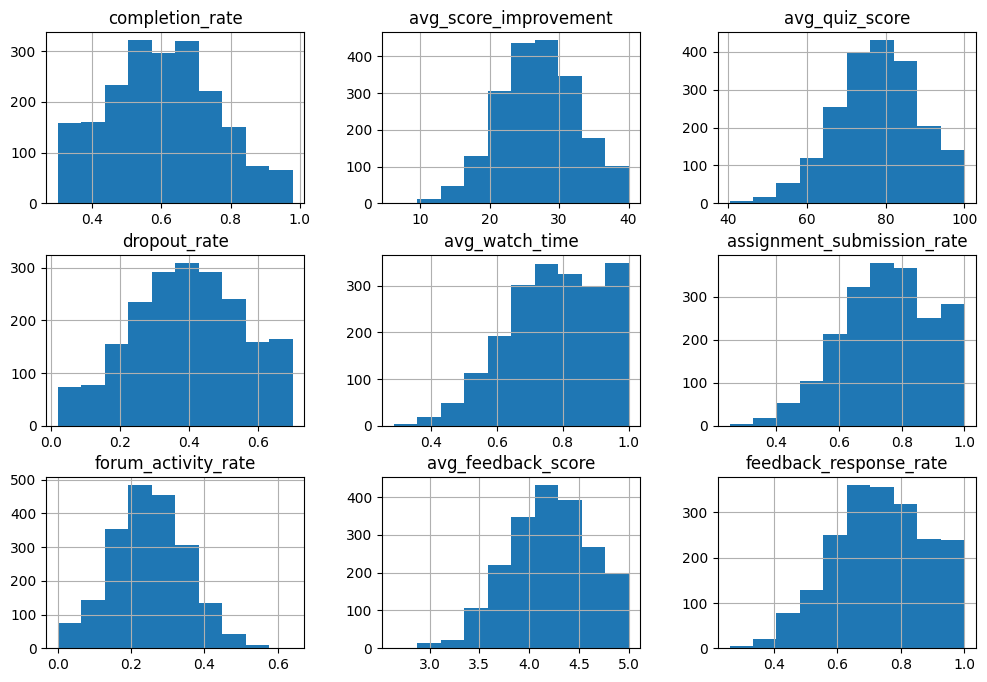

In [5]:
df.hist(figsize=(12,8))
plt.show()

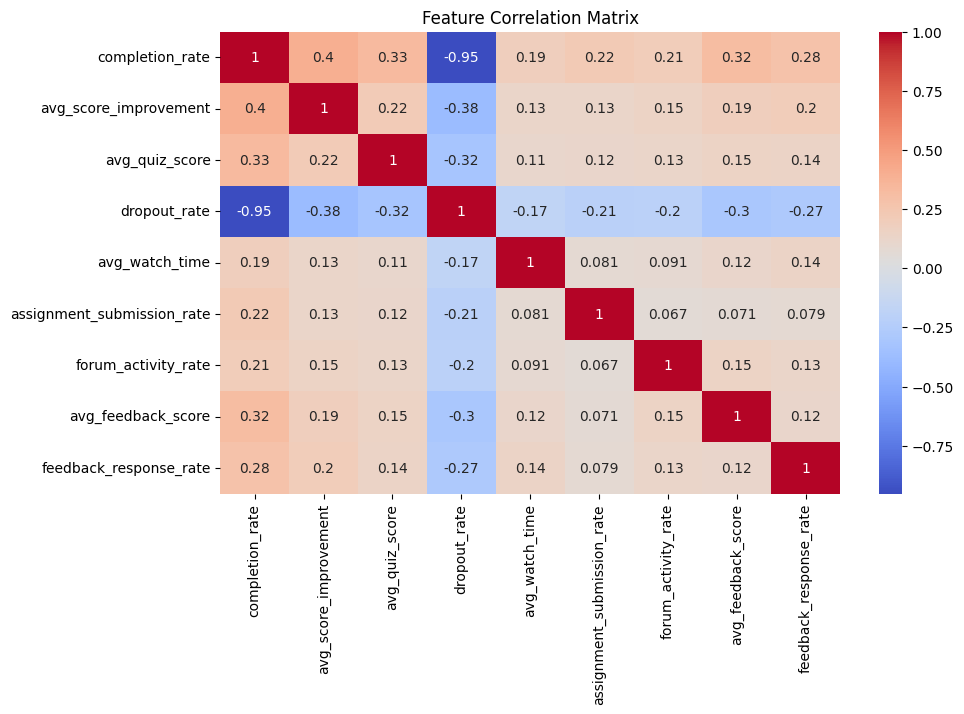

In [7]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

Correlation analysis helps identify relationships between variables.

For example:
• Completion rate may negatively correlate with dropout rate
• Engagement metrics may correlate with feedback score
• Quiz score improvement may indicate teaching effectiveness

Instructor effectiveness is defined as a combination of:

1. Learning Outcomes
2. Student Engagement
3. Student Feedback

Completion rate and dropout rate capture course success.
Score improvement and quiz scores capture learning gains.
Watch time and feedback score represent engagement and student satisfaction.

In [8]:
df["effectiveness_score"] = (
    0.25 * df["completion_rate"] +
    0.20 * (1 - df["dropout_rate"]) +
    0.20 * df["avg_score_improvement"] +
    0.15 * df["avg_quiz_score"] +
    0.10 * df["avg_watch_time"] +
    0.10 * df["avg_feedback_score"]/5
)

The effectiveness score is divided into three tiers using quantiles:

Low Effectiveness
Medium Effectiveness
High Effectiveness

This ensures balanced class distribution.

In [9]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

**using the mean aggregation function.**
Aggregating batch data
Since instructors may teach multiple batches, we aggregate batch-level metrics using the mean.

The mean represents the instructor’s overall teaching performance across batches.

This prevents one unusually good or bad batch from dominating the score.

In [10]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate":"mean",
    "dropout_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean",
    "effectiveness_score":"mean"
}).reset_index()

In [11]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

The mean was chosen because it represents the instructor’s average performance across all batches they taught.

This is appropriate because:

• It smooths out variations across different batches
• It prevents a single unusually good or bad batch from dominating the evaluation
• It provides a fair overall representation of instructor effectiveness

Preparing data for ML:

In [12]:
X = instructor_df.drop(["instructor_id","effectiveness_tier","effectiveness_score"], axis=1)
y = instructor_df["effectiveness_tier"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [14]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       0.67      0.80      0.73         5
      Medium       0.82      0.82      0.82        11

    accuracy                           0.83        24
   macro avg       0.83      0.83      0.83        24
weighted avg       0.85      0.83      0.84        24



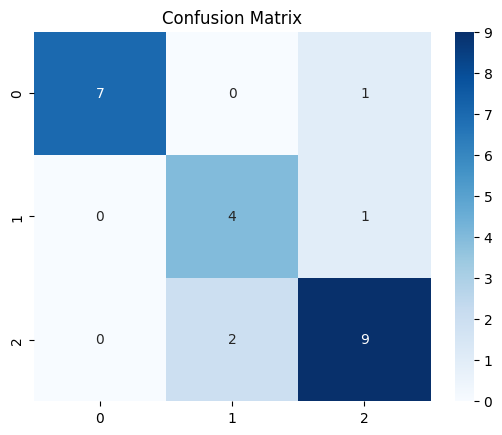

In [17]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Accuracy measures overall prediction performance.

Precision indicates how many predicted instructors in a tier were correct.

Recall indicates how many instructors in a tier were successfully detected.

### Model Choice Justification

A Random Forest classifier was chosen because it performs well on structured tabular data and can capture non-linear relationships between variables. It is also robust to overfitting and requires minimal preprocessing. Additionally, Random Forest provides feature importance scores, which helps identify the factors that most influence instructor effectiveness.

### Model Evaluation

The model was evaluated using the following metrics:

**Accuracy**
Accuracy measures the proportion of correct predictions made by the model across all instructor tiers.

**Precision**
Precision measures how many instructors predicted in a particular effectiveness tier actually belong to that tier.

**Recall**
Recall measures how many instructors belonging to a particular tier were correctly identified by the model.

**Confusion Matrix**
The confusion matrix helps visualize how often the model confuses one effectiveness tier with another.

### Precision vs Recall Trade-off

Precision and recall often have a trade-off. A model with high precision may miss some relevant instructors (lower recall), while a model with high recall may include more incorrect predictions (lower precision).

In this context:
• High precision ensures instructors classified as "High Effectiveness" are truly high-performing.  
• High recall ensures most high-performing instructors are correctly identified.

Depending on the platform's goals, the balance between precision and recall may vary.

In [19]:
instructor_df["effectiveness_tier"].value_counts()

,count
effectiveness_tier,
Low,40
Medium,40
High,40


### Class Imbalance

Class distribution was examined to check whether the dataset is balanced across the three effectiveness tiers (Low, Medium, High).

Since the tiers were created using quantiles, the dataset is relatively balanced. This helps prevent the model from favoring one class over others.

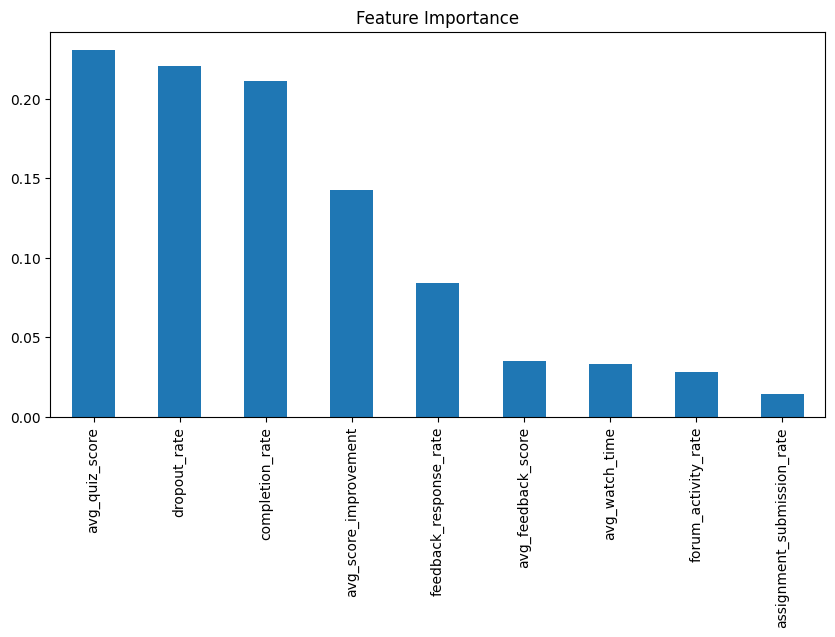

In [20]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar",figsize=(10,5))
plt.title("Feature Importance")
plt.show()

Feature importance shows which metrics most influence instructor effectiveness prediction.

### Interpretation of Results

**Key Features Influencing Instructor Effectiveness**

Based on the feature importance analysis from the Random Forest model, the most influential factors in predicting instructor effectiveness were:

- **Average Quiz Score**
- **Dropout Rate**
- **Completion Rate**
- **Average Score Improvement**

These variables are directly related to **student learning outcomes and course completion**, which are strong indicators of teaching effectiveness.

Engagement and feedback metrics such as **feedback response rate, average feedback score, and watch time** had a smaller but still noticeable influence.

---

### Explanation in Simple Terms

In simple terms, instructors are considered more effective when:

- Students perform well in quizzes
- More students complete the course
- Fewer students drop out
- Students show improvement in their scores

These factors indicate that students are **learning successfully and staying engaged throughout the course**, which reflects positively on the instructor's teaching quality.

---

### How These Insights Could Be Used in an EdTech Product

These insights could help an EdTech platform in several ways:

- **Instructor Performance Dashboard**  
  The platform could track key metrics such as completion rate and quiz performance to evaluate instructor impact.

- **Instructor Training Programs**  
  If certain instructors have higher dropout rates or lower engagement, the platform could provide targeted training or support.

- **Course Improvement**  
  Courses with consistently low engagement or completion rates could be redesigned to improve learning outcomes.

Overall, these insights can help the platform improve **teaching quality, learner engagement, and course success rates.**

###** Mandatory Analysis Questions**



## Mandatory Analysis Questions

### 1. Which features most influenced instructor effectiveness, and why?

Based on the feature importance analysis from the Random Forest model, the most influential features were **average quiz score, dropout rate, completion rate, and average score improvement**.  
These variables directly reflect **student learning outcomes and course success**. Higher quiz scores and score improvement indicate that students are effectively learning from the instructor, while higher completion rates and lower dropout rates suggest that students remain engaged and motivated throughout the course. Therefore, these metrics are strong indicators of instructor effectiveness.



### 2. Which variables could be misleading or confounded?

Some variables may be misleading due to external factors not captured in the dataset. For example, **feedback scores** may be biased because students sometimes rate easier instructors more positively. Similarly, **forum activity rates** may depend more on course difficulty or student motivation rather than instructor quality. Additionally, **dropout rates** may be influenced by course difficulty or learner background rather than purely by teaching effectiveness.



### 3. How could this model fail in real-world usage?

This model may fail if instructors teach **courses of varying difficulty levels**, since harder courses may naturally have lower completion rates and higher dropout rates. It may also fail when **student populations differ significantly**, such as beginners versus advanced learners. Additionally, the model relies only on quantitative metrics and does not capture qualitative aspects of teaching such as clarity of explanation, teaching style, or instructor support.



### 4. What additional data would you want to improve this analysis?

To improve this analysis, additional data could be helpful, such as:
- **Instructor experience and qualifications**
- **Course difficulty level**
- **Class size or number of enrolled students**
- **Student demographics and prior knowledge**
- **Instructor responsiveness to student questions**
- **Time spent interacting with learners**

Including these variables would help provide a more comprehensive and fair evaluation of instructor effectiveness.



### 5. Should this model be used for instructor performance evaluation? Why or why not?

This model should **not be used as the sole measure of instructor performance**. While it can provide useful insights into patterns of learner engagement and outcomes, many external factors influence these metrics. Course difficulty, student motivation, and cohort differences can all affect performance indicators. Therefore, the model should be used as a **supporting analytical tool rather than a definitive evaluation system**, alongside qualitative feedback and expert review.

CONCLUSION:
This analysis demonstrated how instructor effectiveness can be estimated using learner outcomes, engagement, and feedback metrics.

A machine learning model was trained to classify instructors into effectiveness tiers. Feature importance analysis highlighted the key drivers of effective teaching.

However, such models should be used cautiously due to potential biases and missing contextual factors.